<a href="https://colab.research.google.com/github/samrudhi-shirode/AI-Projects/blob/main/Powerplant_Energy_Output_Prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build an ANN model that predicts the power energy generated by the powerplant by taking various sensor readings into consideration.

# Data Gathering

In [1]:
import pandas as pd
path = r"https://raw.githubusercontent.com/samrudhi-shirode/Datasets/refs/heads/main/PowerPlant.csv"
df = pd.read_csv(path)
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


# Perform basic data quality checks

In [2]:
df.shape

(9568, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.duplicated().sum()

np.int64(41)

In [5]:
df = df.drop_duplicates()

In [6]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


# EDA(Exploratory Data Analysis)

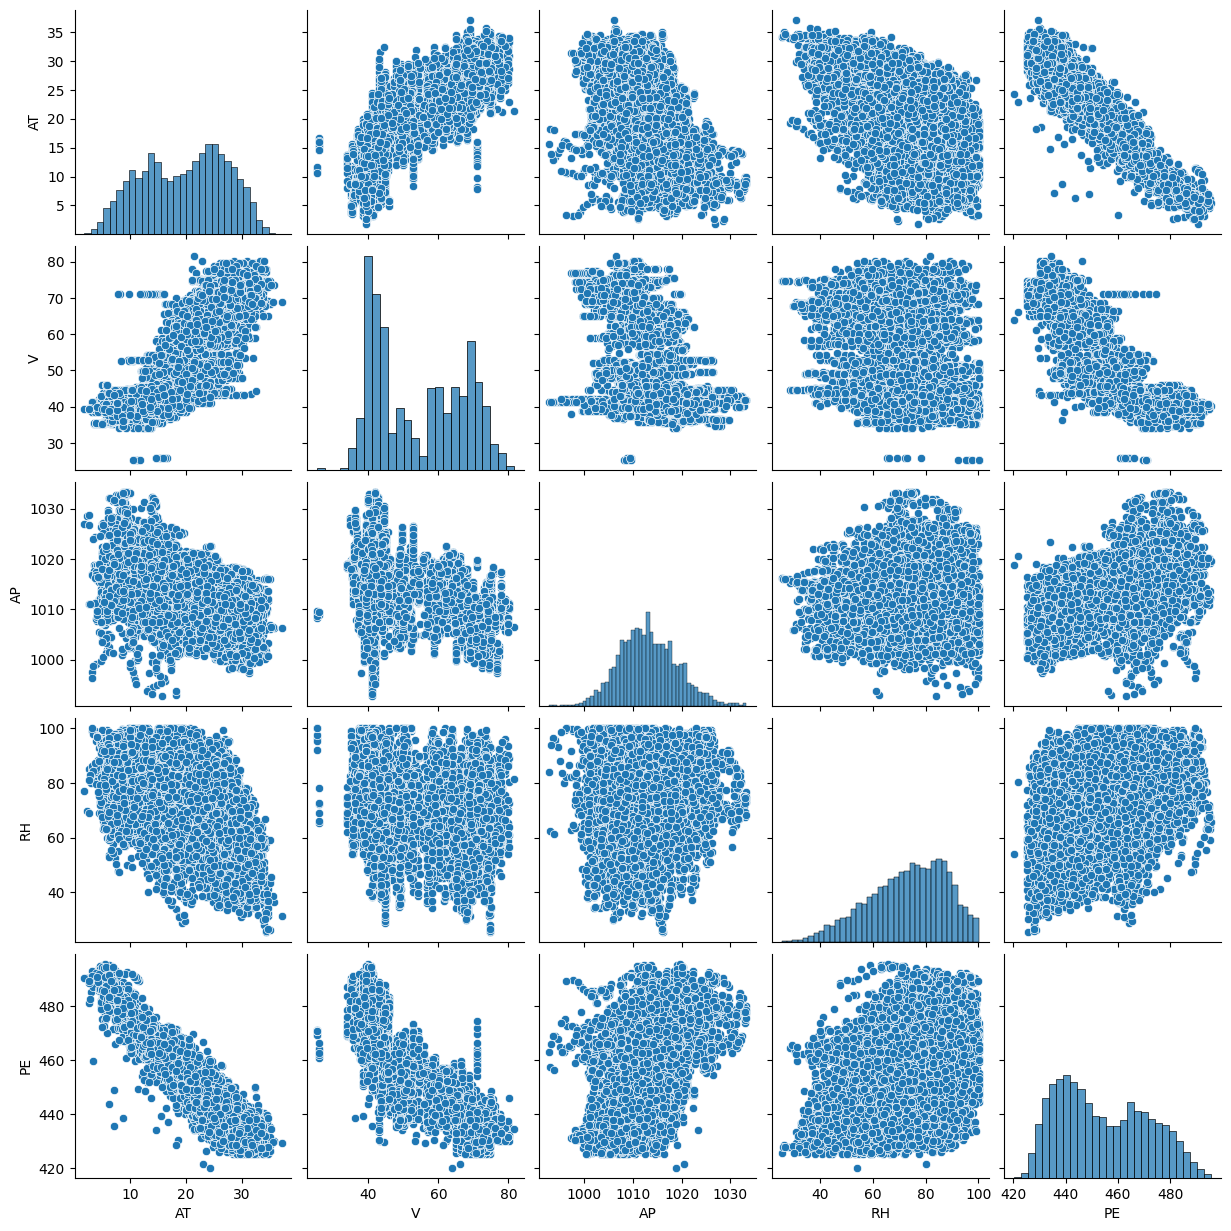

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

# Separate X and Y features

In [8]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [9]:
df.head(2)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75


In [10]:
X = df.drop(columns='PE')
Y = df[['PE']]

In [11]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [12]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43




# Split the data into training and testing


In [15]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.75,random_state=21)

# Feature Engg: Data Cleaning and Data Scaling

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pre = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')



In [16]:
X_train = pre.fit_transform(xtrain)
X_test = pre.transform(xtest)

# Model Building

In [17]:
from keras.models import Sequential
from keras.layers import Dense


In [18]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [21]:
history = model.fit(
    X_train, ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 181419.1094 - mae: 424.0432 - val_loss: 120966.4375 - val_mae: 344.4117
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49415.6406 - mae: 195.3572 - val_loss: 16531.7246 - val_mae: 109.0352
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12435.2080 - mae: 93.8051 - val_loss: 7945.8579 - val_mae: 75.7452
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5666.2563 - mae: 62.5147 - val_loss: 3419.7744 - val_mae: 48.5889
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2490.1936 - mae: 40.5682 - val_loss: 1595.9650 - val_mae: 32.5470
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1248.6411 - mae: 28.3143 - val_loss: 905.5757 - val_mae: 24.1308
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 750.9747 - mae: 21.6936 - val_loss: 590.2904 - val_mae: 19.1719
Epoch 8/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 496.3598 - mae: 17.4770 - val_loss: 402.2

In [22]:
loss, mae = model.evaluate(X_test, ytest)

print("Test MAE:", mae)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.3721 - mae: 3.4242
Test MAE: 3.4242348670959473


In [23]:
y_pred = model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [25]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

print("MSE:", mse)
print("R2 Score:", r2*100)

MSE: 19.372066497802734
R2 Score: 93.33711862564087


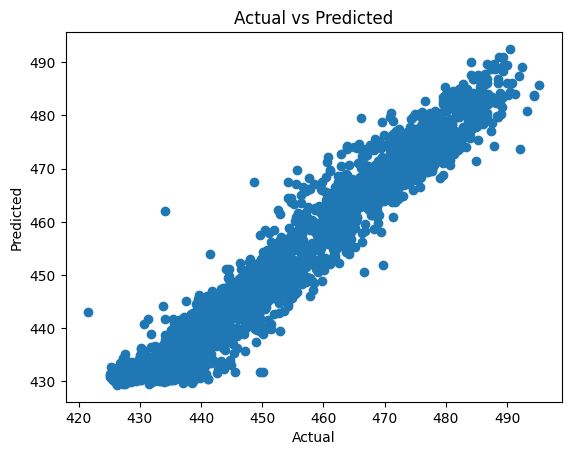

In [27]:
plt.scatter(ytest, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()